In [1]:
import kagglehub
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

Using Colab cache for faster access to the 'sign-language-mnist' dataset.


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [3]:
df_train = pd.read_csv(path + "/sign_mnist_train.csv")
df_test = pd.read_csv(path + "/sign_mnist_test.csv")
df_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [31]:
print(df_train.shape)
print(df_test.shape)

(27455, 785)
(7172, 785)


In [5]:
X_train = df_train.drop("label", axis=1)
y_train = df_train["label"]
X_test = df_test.drop("label", axis=1)
y_test = df_test["label"]



In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train.reshape(-1, 28*28))
X_test_flat = scaler.transform(X_test.reshape(-1, 28*28))

X_train = X_train_flat.reshape(-1, 28, 28, 1)
X_test = X_test_flat.reshape(-1, 28, 28, 1)

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

datagen.fit(X_train)

In [15]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=X_train[0].shape),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),
    Dense(25, activation="softmax")
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

In [25]:
stop = EarlyStopping(monitor="val_loss", patience=3)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)
train_ds = tf.data.Dataset.from_generator(
    lambda: datagen.flow(X_train, y_train, batch_size=32),
    output_signature=(
        tf.TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.int64)
    )
)
history = model.fit(
    train_ds,
    steps_per_epoch=len(X_train) // 32,
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks = [stop, reduce_lr]
)

Epoch 1/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9873 - loss: 0.0390 - val_accuracy: 0.9999 - val_loss: 0.0019 - learning_rate: 5.0000e-04
Epoch 2/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9867 - loss: 0.0410 - val_accuracy: 0.9971 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 3/10
854/857 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9884 - loss: 0.0368
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
857/857 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9882 - loss: 0.0373 - val_accuracy: 0.9999 - val_loss: 0.0027 - learning_rate: 5.0000e-04
Epoch 4/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9906 - loss: 0.0294 - val_accuracy: 0.9989 - val_loss: 0.0030 - learning_rate: 2.5000e-04


Generating predictions on test set...
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000       331
           B     1.0000    1.0000    1.0000       432
           C     1.0000    1.0000    1.0000       310
           D     1.0000    1.0000    1.0000       245
           E     1.0000    1.0000    1.0000       498
           F     1.0000    1.0000    1.0000       247
           G     1.0000    0.9770    0.9884       348
           H     0.9820    1.0000    0.9909       436
           I     1.0000    1.0000    1.0000       288
           K     1.0000    1.0000    1.0000       331
           L     1.0000    1.0000    1.0000       209
           M     1.0000    1.0000    1.0000       394
           N     1.0000    1.0000    1.0000       291
           O     1.0000    1.0000    1.0000       246
           P     1.0000    1.0000    1.0000       347
           Q     1.0000    1.0000

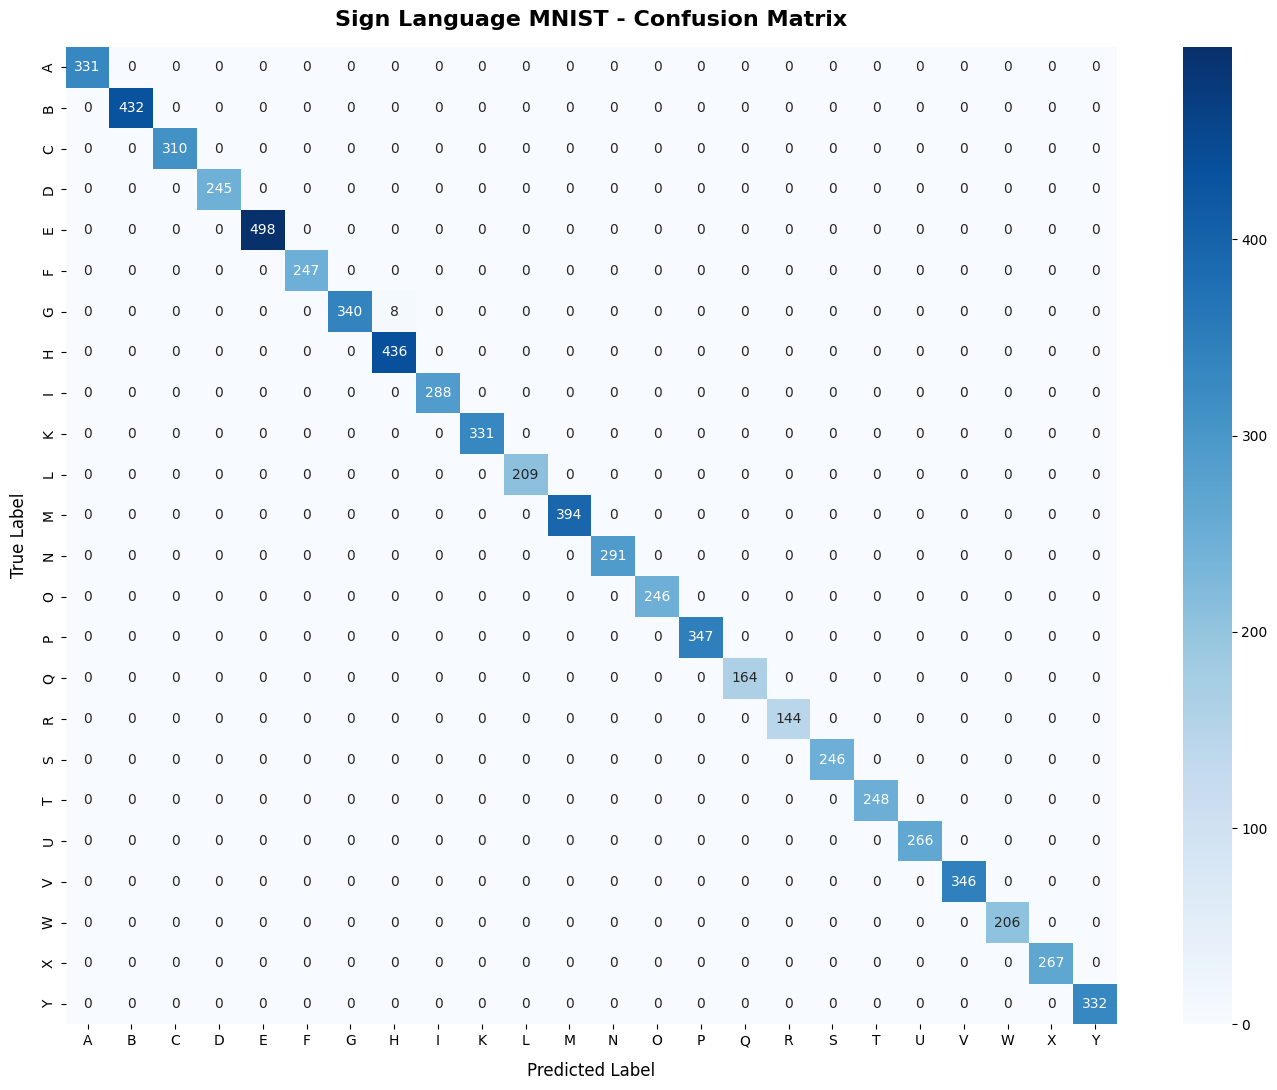

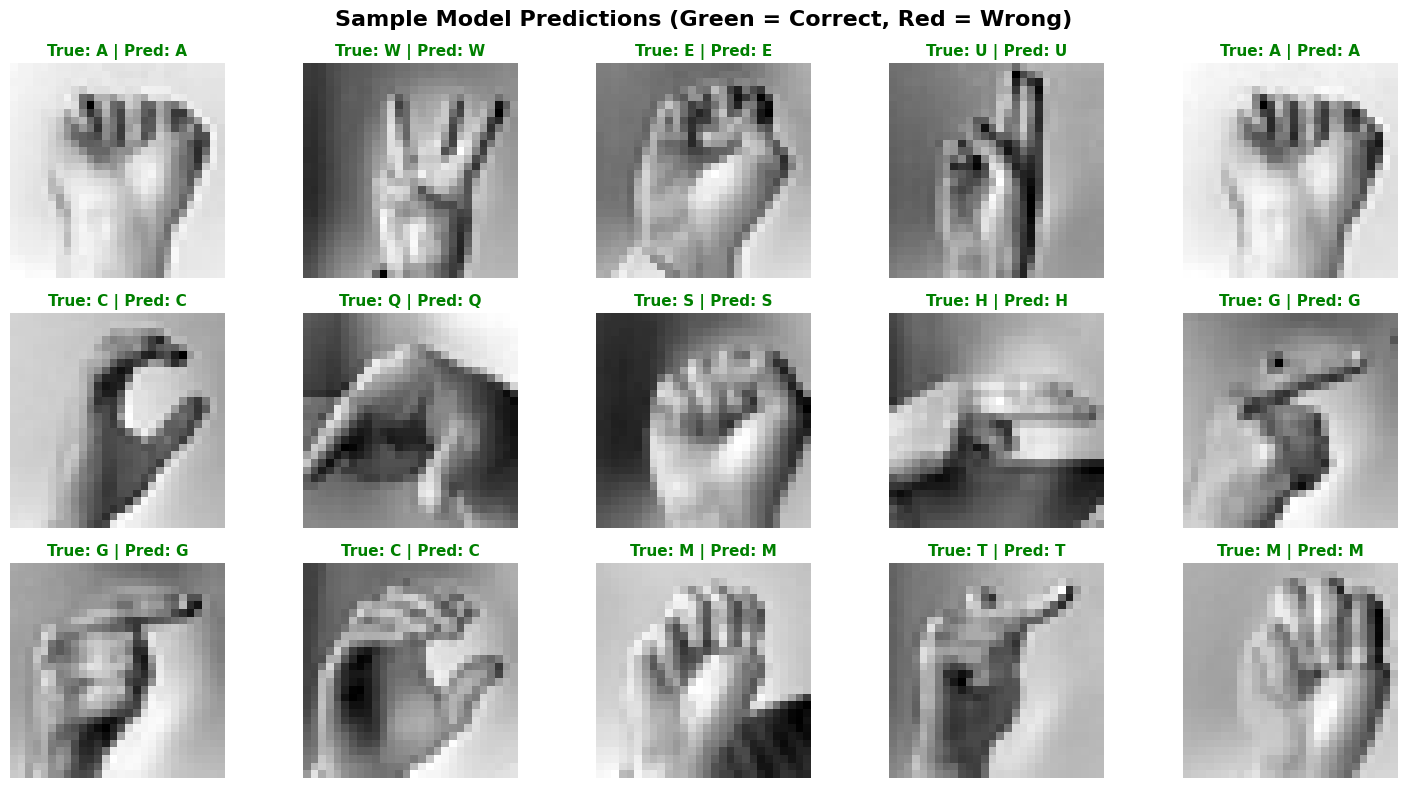

In [30]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

INDEX_TO_LETTER = {
    0: "A",
    1: "B",
    2: "C",
    3: "D",
    4: "E",
    5: "F",
    6: "G",
    7: "H",
    8: "I",
    10: "K",
    11: "L",
    12: "M",
    13: "N",
    14: "O",
    15: "P",
    16: "Q",
    17: "R",
    18: "S",
    19: "T",
    20: "U",
    21: "V",
    22: "W",
    23: "X",
    24: "Y",
}

os.makedirs("assets", exist_ok=True)

# Generate Predictions
print("Generating predictions on test set...")
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Retrieve unique classes present in test/prediction sets and their letter mapping
present_classes = np.unique(np.concatenate([y_test, y_pred]))
target_names = [
    INDEX_TO_LETTER.get(i, f"Class_{i}") for i in present_classes
]

# Print & Save Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
report = classification_report(
    y_test, y_pred, target_names=target_names, digits=4
)
print(report)

with open("assets/classification_report.txt", "w") as f:
    f.write(report)

#Plot & Save Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=True,
)
plt.title(
    "Sign Language MNIST - Confusion Matrix", fontsize=16, pad=15, weight="bold"
)
plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
plt.ylabel("True Label", fontsize=12, labelpad=10)
plt.tight_layout()

cm_path = "assets/confusion_matrix.png"
plt.savefig(cm_path, dpi=300)
plt.show()

#Plot & Save Sample Predictions Grid
plt.figure(figsize=(15, 8))
np.random.seed(42)
indices = np.random.choice(len(X_test), 15, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 5, i + 1)
    img = X_test[idx].reshape(28, 28)
    plt.imshow(img, cmap="gray")

    true_idx = y_test[idx]
    pred_idx = y_pred[idx]

    true_label = INDEX_TO_LETTER.get(true_idx, str(true_idx))
    pred_label = INDEX_TO_LETTER.get(pred_idx, str(pred_idx))

    is_correct = true_idx == pred_idx
    color = "green" if is_correct else "red"

    plt.title(
        f"True: {true_label} | Pred: {pred_label}",
        color=color,
        fontsize=11,
        weight="bold",
    )
    plt.axis("off")

plt.suptitle(
    "Sample Model Predictions (Green = Correct, Red = Wrong)",
    fontsize=16,
    weight="bold",
    y=0.98,
)
plt.tight_layout()

grid_path = "assets/sample_predictions.png"
plt.savefig(grid_path, dpi=300)
plt.show()